In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import (
    StandardScaler,
    Normalizer,
    FunctionTransformer,
    OneHotEncoder,
    OrdinalEncoder,
    SplineTransformer,
)
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.feature_extraction import FeatureHasher
from sklearn.compose import make_column_transformer
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split, cross_val_score


In [22]:
# Revisit the OKCupid data
df = pd.read_csv("../04_categorical/profiles_revised.csv")

In [23]:
# Target: predict if job is stem related
df["job"].value_counts()
df["stem_job"] = df["job"].str.contains("computer|science|engineer|math", case=False, na=False)
df.drop(columns="job", inplace=True)
df["stem_job"].value_counts() / len(df)

stem_job
False    0.840573
True     0.159427
Name: count, dtype: float64

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 59946 entries, 0 to 59945
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          59946 non-null  int64  
 1   body_type    54650 non-null  str    
 2   diet         35551 non-null  str    
 3   drinks       56961 non-null  str    
 4   drugs        45866 non-null  str    
 5   education    53318 non-null  str    
 6   ethnicity    54266 non-null  str    
 7   height       59943 non-null  float64
 8   income       59946 non-null  int64  
 9   offspring    24385 non-null  str    
 10  orientation  59946 non-null  str    
 11  pets         40025 non-null  str    
 12  religion     39720 non-null  str    
 13  sex          59946 non-null  str    
 14  sign         48890 non-null  str    
 15  smokes       54434 non-null  str    
 16  speaks       59896 non-null  str    
 17  status       59946 non-null  str    
 18  stem_job     59946 non-null  bool   
dtypes: bool(1), flo

In [25]:
# train, test = train_test_split(df, test_size=0.25, random_state=322, stratify=df[["stem_job"]])

## Understanding missing values
In addition to looking at how many of which feature are missing, it's useful to understand whether missing values tend to co-occur.

In [26]:
# Store a copy before we mess with it
og_df = df.copy()

In [27]:
# set income < 0 to missing
df.loc[df["income"] < 0, "income"] = np.nan
df.head()

,age,body_type,diet,drinks,drugs,education,ethnicity,height,income,offspring,orientation,pets,religion,sex,sign,smokes,speaks,status,stem_job
0,22,a little extra,strictly anything,socially,never,working on college/university,"asian, white",75.0,NaN,"doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism and very serious about it,m,gemini,sometimes,english,single,False
1,36,average,mostly other,often,sometimes,working on space camp,white,70.0,80000.0,"doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism but not too serious about it,m,cancer,no,"english (fluently), spanish (poorly), french (...",single,False
2,37,thin,anything,socially,NaN,graduated from masters program,NaN,68.0,NaN,NaN,straight,has cats,NaN,m,pisces but it doesn&rsquo;t matter,no,"english, french, c++",available,False
3,22,thin,vegetarian,socially,NaN,working on college/university,white,71.0,20000.0,doesn&rsquo;t want kids,straight,likes cats,NaN,m,pisces,no,"english, german (poorly)",single,False
4,30,athletic,NaN,socially,never,graduated from college/university,"asian, black, other",66.0,NaN,NaN,straight,likes dogs and likes cats,NaN,m,aquarius,no,english,single,False


In [28]:
print("Missing values by percentage of dataset")
df.isna().sum().sort_values(ascending=False) / len(df) * 100

Missing values by percentage of dataset


income         80.809395
offspring      59.321723
diet           40.694959
religion       33.740366
pets           33.231575
drugs          23.487806
sign           18.443266
education      11.056618
ethnicity       9.475194
smokes          9.194942
body_type       8.834618
drinks          4.979482
speaks          0.083408
height          0.005005
age             0.000000
orientation     0.000000
sex             0.000000
status          0.000000
stem_job        0.000000
dtype: float64

In [ ]:
# Should split, but don't want to replace variable names right now
# TODO: split and stratify by target

Text(0, 0.5, 'Number of samples')

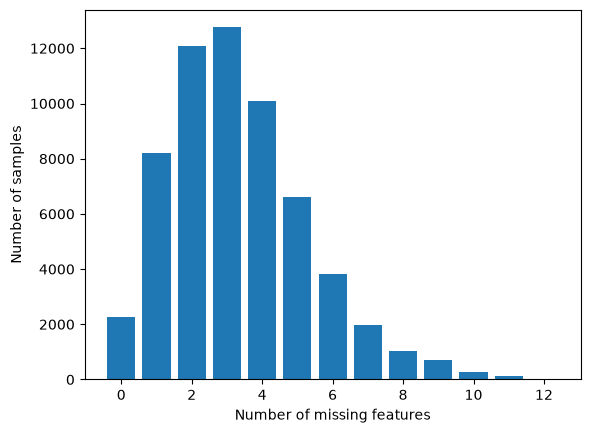

In [29]:
# How many missing values per sample?
missing_per_sample = df.isna().sum(axis=1).value_counts()
plt.bar(missing_per_sample.index, missing_per_sample)
plt.xlabel("Number of missing features")
plt.ylabel("Number of samples")

In [37]:
df.isna().sum(axis=1).sort_values(ascending=False)
df.loc[31651]

age                  32
body_type           NaN
diet                NaN
drinks              NaN
drugs               NaN
education           NaN
ethnicity           NaN
height             70.0
income              NaN
offspring           NaN
orientation    straight
pets                NaN
religion            NaN
sex                   m
sign                NaN
smokes              NaN
speaks          english
status           single
stem_job          False
Name: 31651, dtype: object

<Axes: >

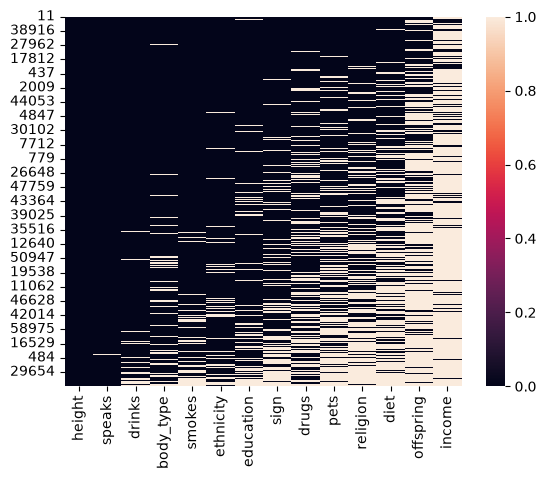

In [30]:
# Maybe a heatmap can show trends?
# number of missing per sample
missing_samples = df.isna().sum(axis=1).sort_values()
# drop with none missing and sort 
missing_samples.drop(missing_samples[missing_samples == 0].index, inplace=True)

# Features with samples missing
missing_features = df.isna().sum(axis=0).sort_values()
missing_features.drop(missing_features[missing_features == 0].index, inplace=True)

sns.heatmap(df.loc[missing_samples.index, missing_features.index].isna())

In [31]:
df.loc[missing_samples.index, missing_features.index].isna()

,height,speaks,drinks,body_type,smokes,ethnicity,education,sign,drugs,pets,religion,diet,offspring,income
11,False,False,False,False,False,False,False,False,False,False,False,False,True,False
7,False,False,False,False,False,False,False,False,False,False,False,False,False,True
10484,False,False,False,False,False,False,False,False,False,False,False,False,False,True
10479,False,False,False,False,False,False,False,False,False,False,False,False,False,True
10477,False,False,False,False,False,False,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17837,False,False,True,True,True,True,True,True,True,True,True,True,True,True
38797,False,False,True,True,True,True,True,True,True,True,True,True,True,True
37355,False,False,True,True,True,True,True,True,True,True,True,True,True,True
54200,False,False,True,True,True,True,True,True,True,True,True,True,True,True


<Axes: >

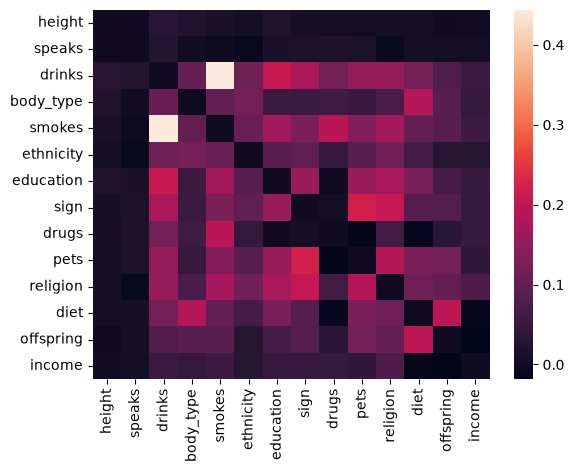

In [32]:
# how about correlations between missing values?
missing_cor = df.loc[missing_samples.index, missing_features.index].isna().corr()
# zero out the diagonal so we can visualize it better
missing_cor -= np.identity(missing_cor.shape[0])
sns.heatmap(missing_cor)

In [33]:
# before looking at relationship to target, split the data
train, test = train_test_split(df, stratify=df["stem_job"], random_state=12345)

income       36329
offspring    26598
diet         18268
religion     15231
pets         14973
drugs        10512
dtype: int64


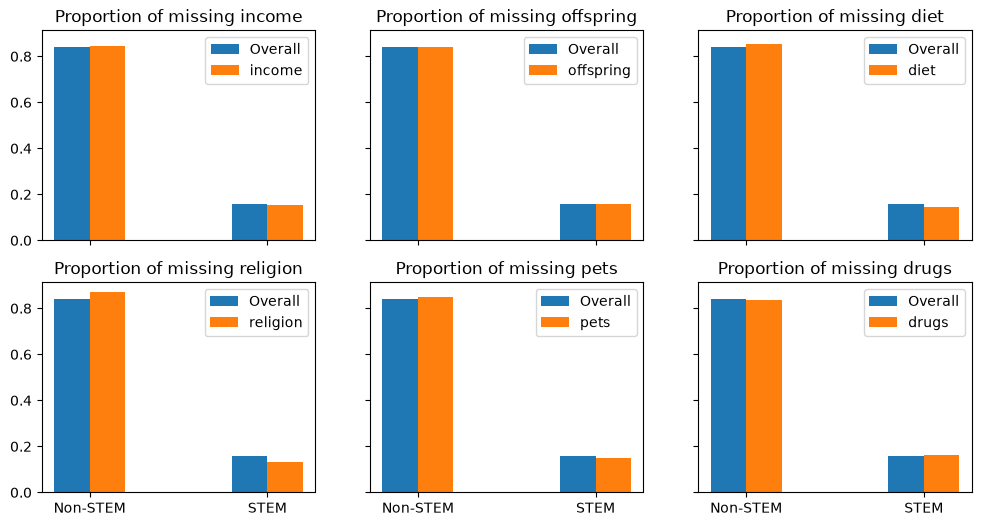

In [34]:
# look at the ones that have a lot missing
train_missing = train.isna().sum(axis=0).sort_values(ascending=False)
# filter down to the > 20% missing
n_missing = train_missing[train_missing > 0.2 * len(train)]
print(n_missing)

# percentage in each target category
train_prop = train["stem_job"].value_counts() / len(train)
fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True, sharey=True)
for feat, ax in zip(n_missing.index, axes.flatten()):
    counts = train.groupby("stem_job")[feat].apply(lambda x: x.isna().sum())
    # normalize
    counts /= n_missing[feat]
    # compare to the overall proportion of stem/not stem
    ax.bar([-0.1, .9], train_prop, width=0.2, label="Overall")
    ax.bar([0.1, 1.1], counts, width=0.2, label=f"{feat}")
    ax.set_xticks([0, 1], labels=["Non-STEM", "STEM"])
    ax.set_title(f"Proportion of missing {feat}")
    ax.legend()

# Look at value_counts for the features with lots of missing data, grouped by stem_job


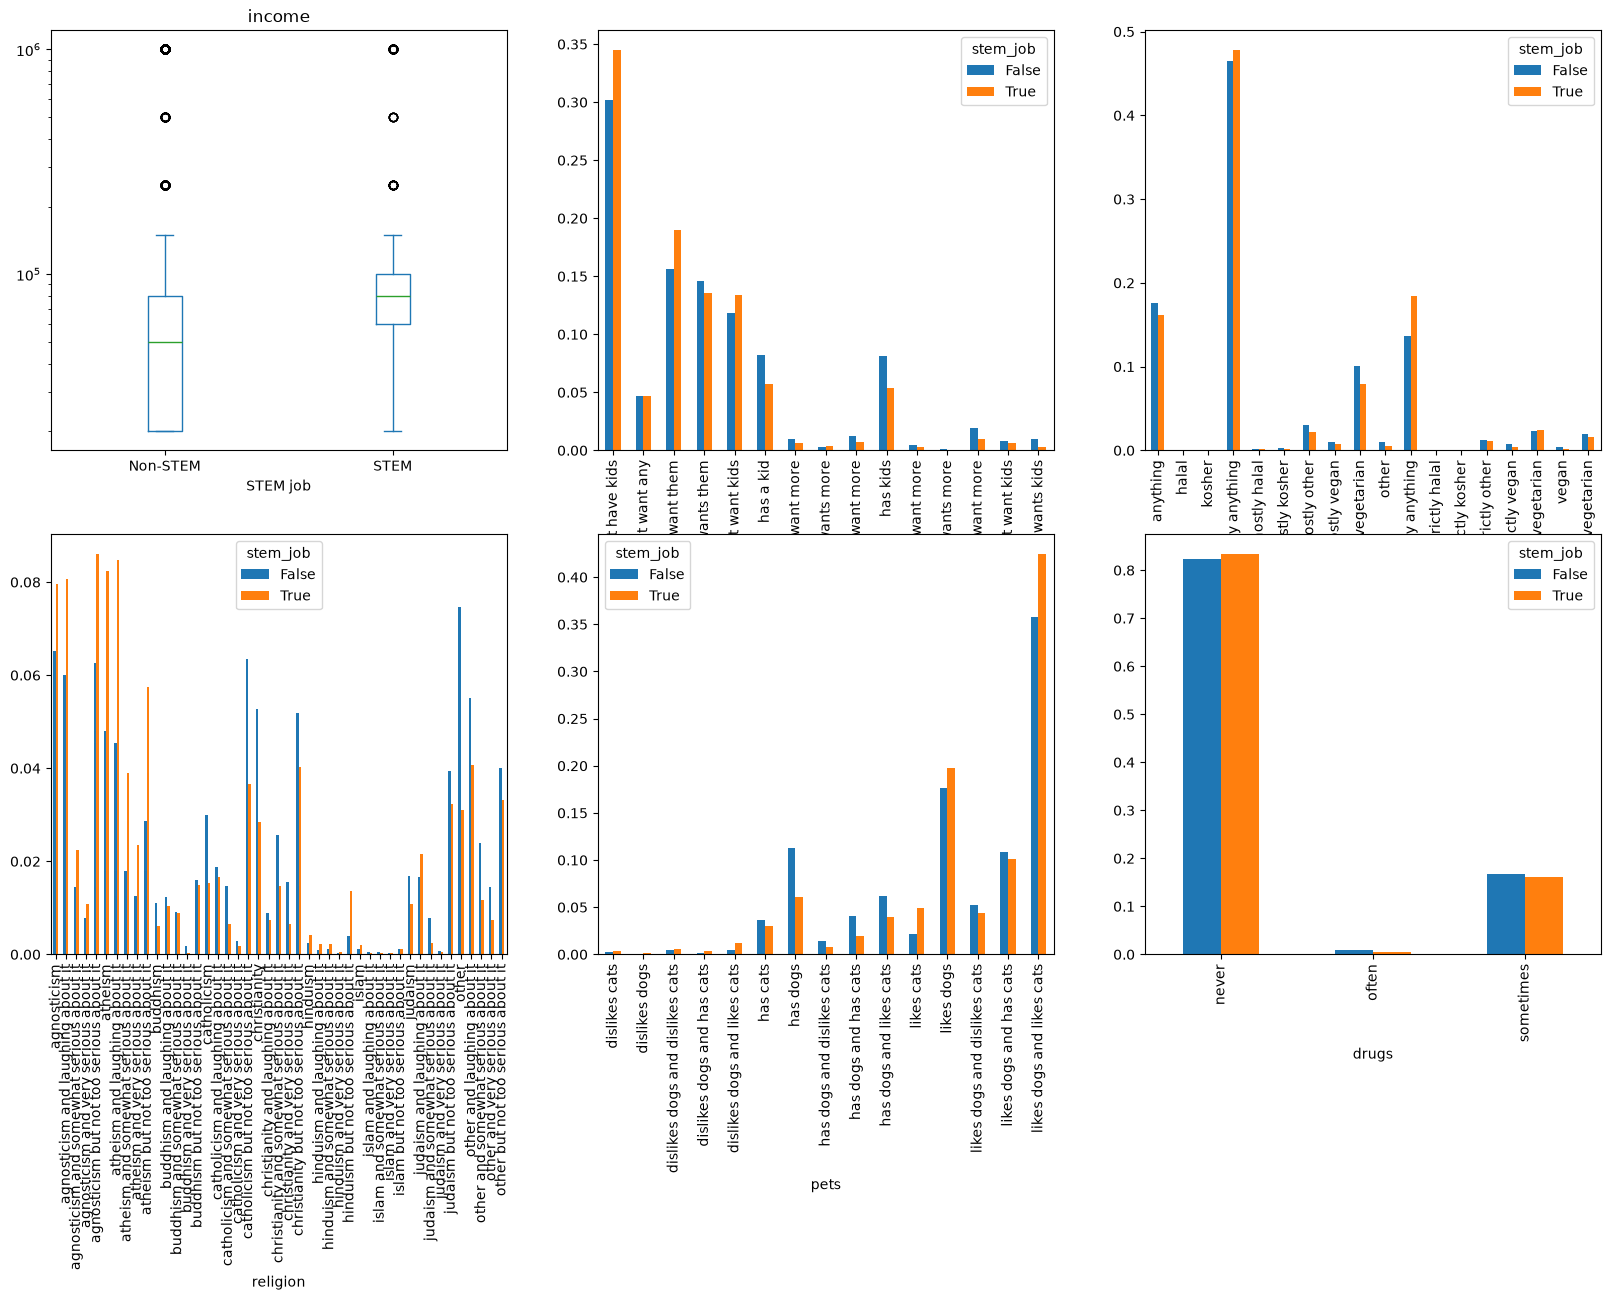

In [35]:
# what about the non-missing values from categories with a lot missing?
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
for feat, ax in zip(n_missing.index, axes.flatten()):
    # income is the only continuous one, do a box plot
    if feat == "income":
        train[["income", "stem_job"]].dropna().plot.box(column="income", ax=ax,by="stem_job")
        ax.set_xlabel("STEM job")
        ax.set_xticks([1,2], labels=["Non-STEM", "STEM"])
        ax.set_yscale("log")
    else:
        # categorical needs value_counts
        # Thanks to https://stackoverflow.com/questions/48238305/bar-plot-with-groupby for unstack(0) magic
        feat_cat_counts = train[[feat, "stem_job"]].dropna().groupby("stem_job")[feat].value_counts().unstack(0)
        
        # normalize by total number in each stem category
        feat_cat_counts /= feat_cat_counts.sum()
        # plot magic
        feat_cat_counts.plot.bar(ax=ax)


## Dealing with missing values

In [ ]:
# select features to use in the model
numeric_features = ["age", "height", "income"]
cat_features = ["drinks", "education", "sex","pets","religion","offspring"]

In [ ]:
for cat in cat_features:
    print(cat,"cardinality:")
    print(len(train[cat].value_counts()))

In [ ]:
# Define the trickier encoders
drink_enc = OrdinalEncoder(
            categories=[
                [
                    "not at all",
                    "rarely",
                    "socially",
                    "often",
                    "very often",
                    "desperately",
                ]
            ],
            handle_unknown="use_encoded_value",
            unknown_value=-1,
        )

# This took a while mucking around to figure out the right magic between df/series
def split_edu(df):
    edu = df["education"].copy()
    edu[edu.isna()] = ""
    return edu.str.split(" ")

# poorly named, now using for two different features
edu_enc = make_pipeline(
        FunctionTransformer(split_edu, validate=False),
        FeatureHasher(n_features=8, input_type="string"),
    )

def split_religion(df):
    edu = df["religion"].copy()
    edu[edu.isna()] = ""
    return edu.str.split(" ")

# poorly named, now using for two different features
religion_enc = make_pipeline(
        FunctionTransformer(split_religion, validate=False),
        FeatureHasher(n_features=16, input_type="string"),
    )


Iterations
1. Initial guess (same as 05_numeric/numericdemo.ipynb): array([0.68783959, 0.67537844, 0.68029499, 0.69439772, 0.6787424 ])
2. Adding on pets, offspring, religion: array([0.69434752, 0.68200837, 0.73779637, 0.69177127, 0.72365666])
3. increase religion feature hash size to 16: array([0.71598046, 0.67991632, 0.67782427, 0.73361227, 0.78087927])
4. Log transform the income: array([0.65903025, 0.69461744, 0.24354982, 0.4006895 , 0.67467467]) -> bad idea, keep the power transformer

In [ ]:
# Build the preprocessing pipeline

numeric_pipeline = make_pipeline(
    SimpleImputer(strategy="mean", add_indicator=True),
    # StandardScaler(),
    PowerTransformer(method="yeo-johnson"),
)

income_pipeline = make_pipeline(
    SimpleImputer(strategy="mean", add_indicator=True),
    FunctionTransformer(np.log1p),
)

preprocessor = make_column_transformer(
    (numeric_pipeline, ["age", "height"]),
    (income_pipeline, ["income"]),
    (OneHotEncoder(handle_unknown="ignore"), ["sex","pets","offspring"]),
    (drink_enc, ["drinks"]),
    (edu_enc, ["education"]),
    (religion_enc, ["religion"])

)
preprocessor

In [ ]:
pro_out = preprocessor.fit_transform(train)
plt.hist(pro_out[:,0].todense(), bins=50)

In [ ]:
# Now add on a model!
pipeline = make_pipeline(
    preprocessor,
    SGDClassifier(class_weight="balanced"), #class_weight="balanced" does some magic
)

cross_val_score(pipeline, train, train["stem_job"])

## Extra plots used in slides

In [ ]:
# assume -1 is encoding missingness
plt.hist(og_df[og_df["income"] > 0]["income"], bins=50)
plt.xlabel("Income > 0 in OKCupid Dataset")
plt.ylabel("Number of instances")
plt.savefig("../../static/img/06-income-hist.png")

In [ ]:
# assume -1 is encoding missingness
log_inc = np.log(og_df[og_df["income"] > 0]["income"])
plt.hist(log_inc, bins=50)
plt.xlabel("Income > 0 in OKCupid Dataset")
plt.ylabel("Log number of instances")
plt.savefig("../../static/img/06-income-hist-log.png")

In [ ]:
# What about boxplots vs STEM?
# Only use the training data since we're looking at relationship with predictor
plot_df = train[train["income"] > 0]
fig, ax = plt.subplots()
plot_df.plot.box(column="income", ax=ax,by="stem_job")
ax.set_xlabel("STEM job")
ax.set_xticks([1,2], labels=["Non-STEM", "STEM"])
ax.set_ylabel("Income (> 0)")
plt.yscale("log")
plt.savefig("../../static/img/06-income-boxplot.png")

In [ ]:
# Those outliers are all overlapping, try spreading them out with jitter
fig, ax = plt.subplots()
plot_df.query("income < 140000").plot.box(column="income", ax=ax,by="stem_job")
ax.set_xlabel("STEM job")
ax.set_xticks([1,2], labels=["Non-STEM", "STEM"])
ax.set_ylabel("Income (> 0)")
plt.yscale("log")

# we need a random number generator
rng = np.random.default_rng(seed=67)
outliers = plot_df.query("income >= 140000")
jit_x = rng.normal(size=outliers.shape[0], scale=0.1) + 1 + outliers["stem_job"] * 1
jit_y = rng.normal(size=outliers.shape[0], scale=10000) + outliers["income"] 
plt.scatter(jit_x, jit_y, alpha=0.3)
